# Predictive Analytics (Machine Learning)

An end-to-end **regression** workflow: cleaning data, engineering features, training and comparing models, and evaluating results.

**What it demonstrates**
- A full scikit-learn pipeline (imputation, train/test split, modelling)
- Comparing Linear Regression vs Random Forest
- Evaluating with error metrics and visualising results

**Stack:** Python · scikit-learn · pandas · matplotlib · seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

import warnings

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
warnings.filterwarnings("ignore")

print("Libraries succesfully imported!")

Libraries succesfully imported!


In [2]:
file_path = "Supplement_Sales_weekly.csv"

df = pd.read_csv(file_path)

df.shape

(4384, 8)

In [3]:
df

,Date,Product Name,Category,Units Sold,Price,Discount,Location,Platform
0,2020-01-06,Whey Protein,Protein,161,31.98,0.03,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,135,42.51,0.04,UK,Amazon
2,2020-01-06,Fish Oil,Omega,2604,12.91,0.25,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,949,16.07,0.08,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,551,35.47,0.25,Canada,iHerb
...,...,...,...,...,...,...,...,...
4379,2025-03-31,Melatonin,Sleep Aid,300,47.79,0.21,USA,iHerb
4380,2025-03-31,Biotin,Vitamin,538,38.12,0.22,UK,Walmart
4381,2025-03-31,Green Tea Extract,Fat Burner,1682,20.40,0.12,USA,iHerb
4382,2025-03-31,Iron Supplement,Mineral,2093,18.31,0.23,Canada,Amazon


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          4384 non-null   str    
 1   Product Name  4384 non-null   str    
 2   Category      4384 non-null   str    
 3   Units Sold    4384 non-null   int64  
 4   Price         4376 non-null   float64
 5   Discount      4379 non-null   float64
 6   Location      4384 non-null   str    
 7   Platform      4384 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 437.8 KB


In [8]:
print("\nDescriptive statistics of the numerical columns")
display(df.describe())


Descriptive statistics of the numerical columns


,Units Sold,Price,Discount
count,4384.000000,4376.000000,4379.000000
mean,525.950046,34.797036,0.124323
std,569.893154,14.187780,0.071822
min,16.000000,10.000000,0.000000
25%,135.000000,22.610000,0.060000
50%,312.500000,34.720000,0.120000
75%,717.250000,46.710000,0.190000
max,4869.000000,59.970000,0.250000


In [9]:
print("\nDescriptive statistics of the categorical columns")
display(df.describe(include=['object']))


Descriptive statistics of the categorical columns


,Date,Product Name,Category,Location,Platform
count,4384,4384,4384,4384,4384
unique,274,16,10,3,3
top,2020-01-06,Whey Protein,Vitamin,Canada,iHerb
freq,16,274,822,1507,1499


In [11]:
df.isnull().sum()

Date            0
Product Name    0
Category        0
Units Sold      0
Price           8
Discount        5
Location        0
Platform        0
dtype: int64

In [12]:
print("Handling missing values with Using Mean Imputation")

cols_with_null = ["Price", "Discount"]

mean_imputer = SimpleImputer(strategy="mean")

df[cols_with_null] = mean_imputer.fit_transform(df[cols_with_null])

print(df.isnull().sum())

Handling missing values with Using Mean Imputation
Date            0
Product Name    0
Category        0
Units Sold      0
Price           0
Discount        0
Location        0
Platform        0
dtype: int64


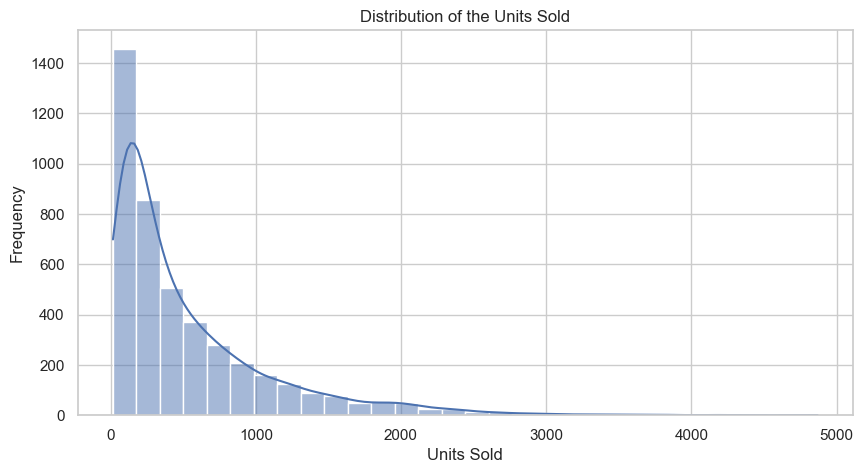

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df["Units Sold"], kde = True, bins = 30)
plt.title("Distribution of the Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()



Analysing Distribution of Numerical Columns


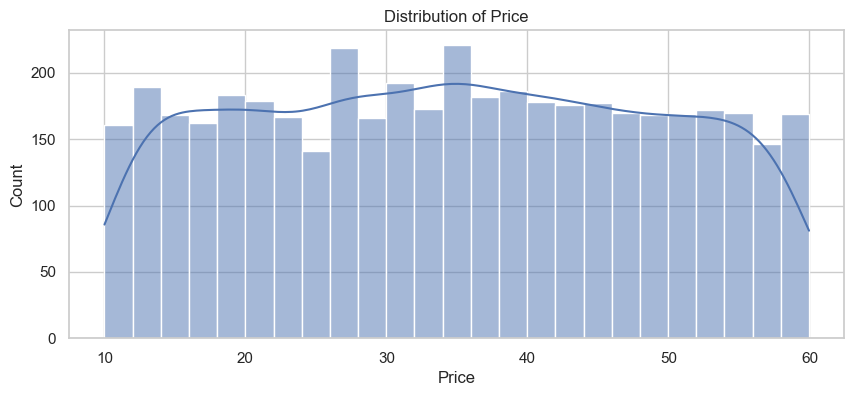

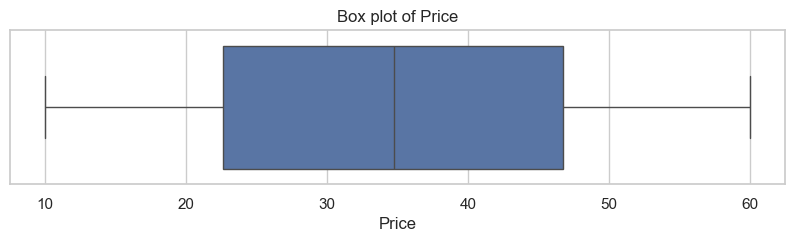

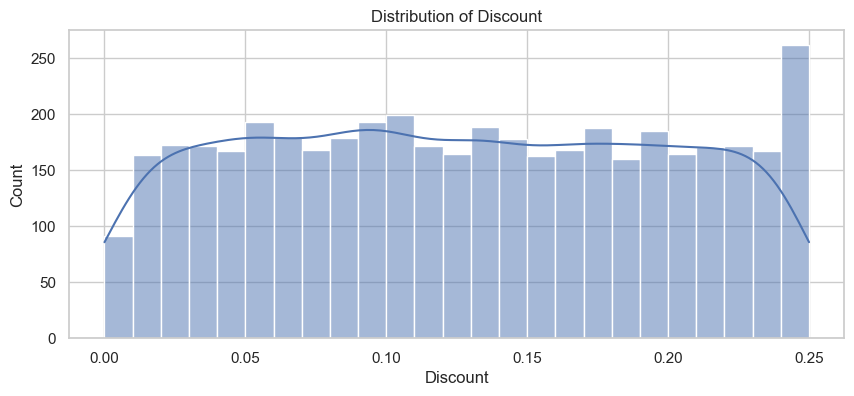

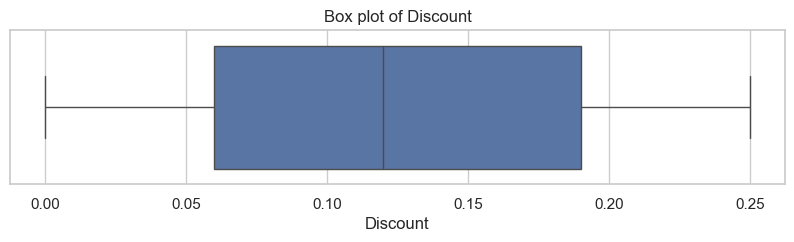

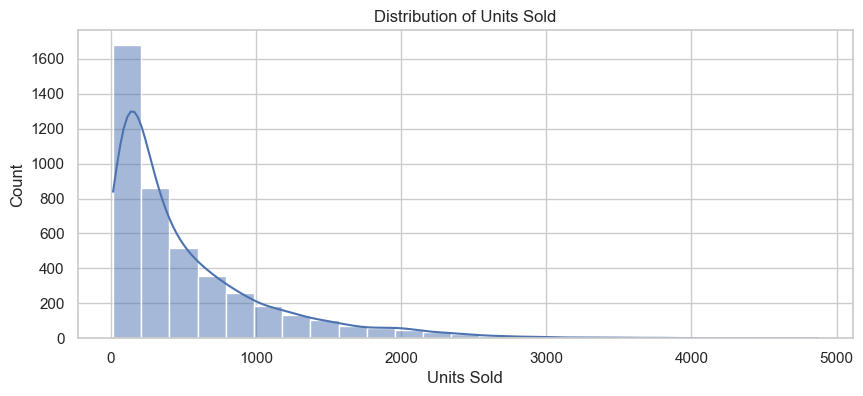

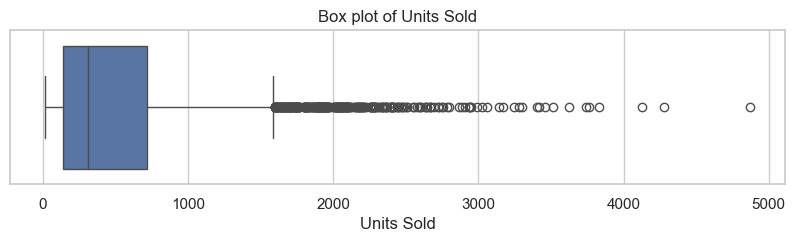

In [16]:
print("\nAnalysing Distribution of Numerical Columns")

num_cols = ["Price", "Discount", "Units Sold"]

for col in num_cols:
    plt.figure(figsize= (10,4))
    sns.histplot(df[col], kde = True, bins = 25)
    plt.title(f"Distribution of {col}")
    plt.show()

    plt.figure(figsize = (10, 2))
    sns.boxplot(x = df[col])
    plt.title(f"Box plot of {col}")
    plt.show()

    print("=" * 150)


Analyzing distributions of categorical features:


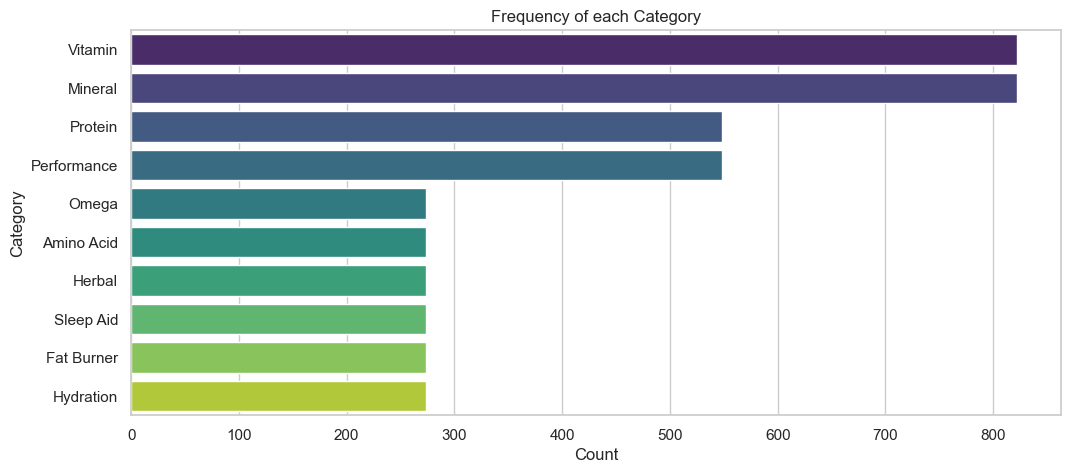

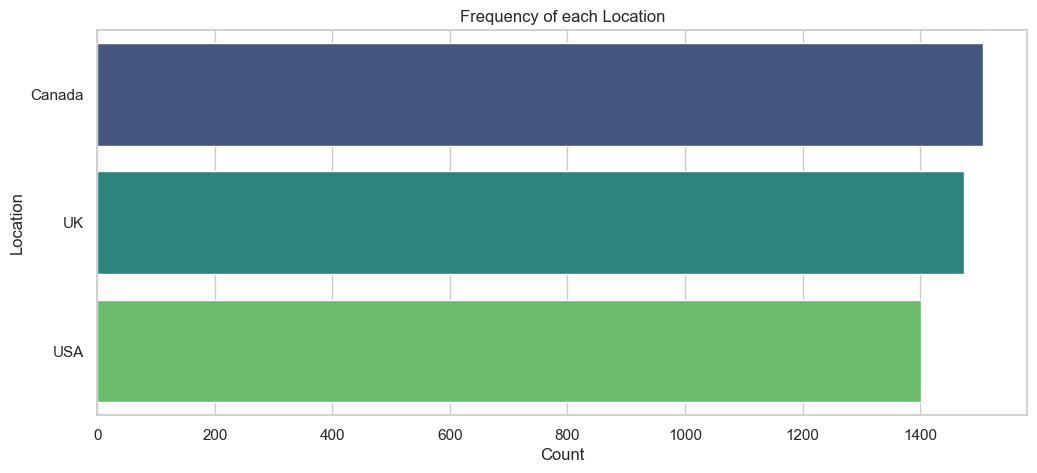

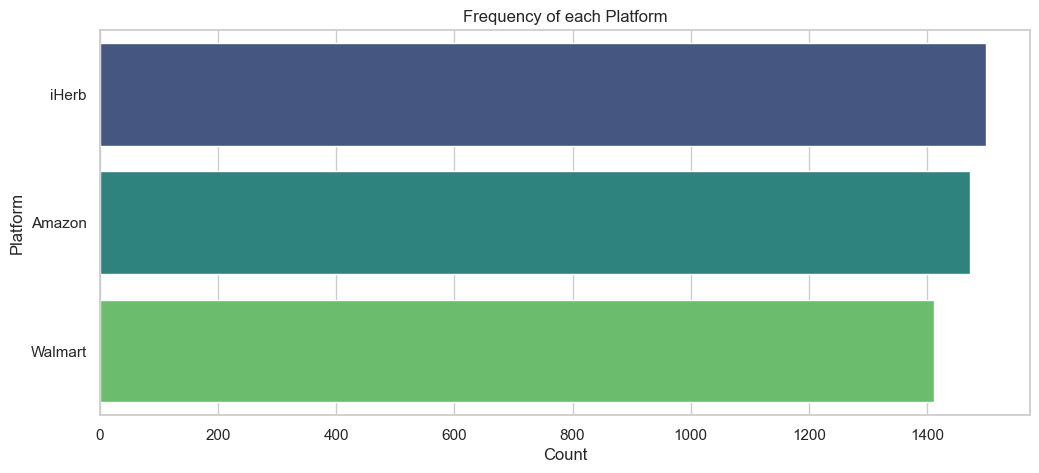

In [17]:
categorical_features = ["Category", "Location", "Platform"]
print("\nAnalyzing distributions of categorical features:")

for col in categorical_features:
    plt.figure(figsize = (12,5))
    sns.countplot(y=df[col], order = df[col].value_counts().index, palette = "viridis")
    plt.title(f"Frequency of each {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

    print("=" * 150)


Analyzing relationships between numerical features and Revenue:


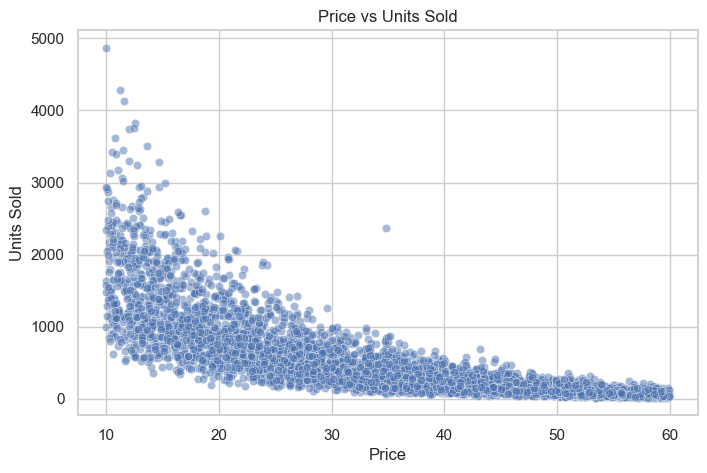

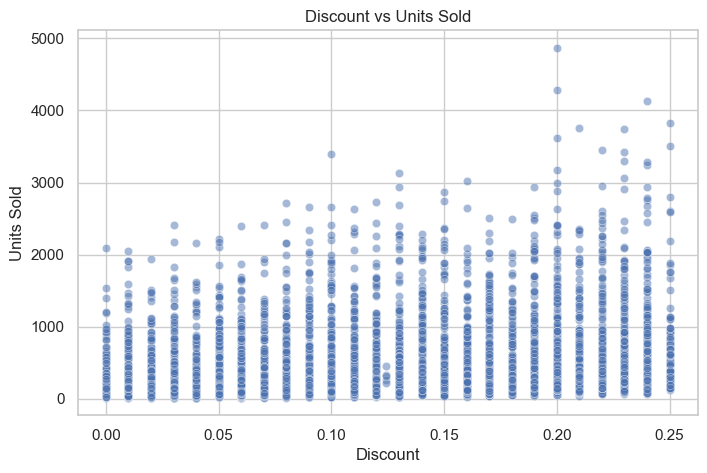

In [20]:
print("\nAnalyzing relationships between numerical features and Revenue:")
numerical_predictors = ["Price", "Discount"]

for col in numerical_predictors:
    plt.figure(figsize = (8,5))
    sns.scatterplot(x = df[col], y = df["Units Sold"], alpha = 0.5)
    plt.title(f"{col} vs Units Sold")
    plt.show()


Correlation Matrix Heatmap (Numerical Features including Revenue):


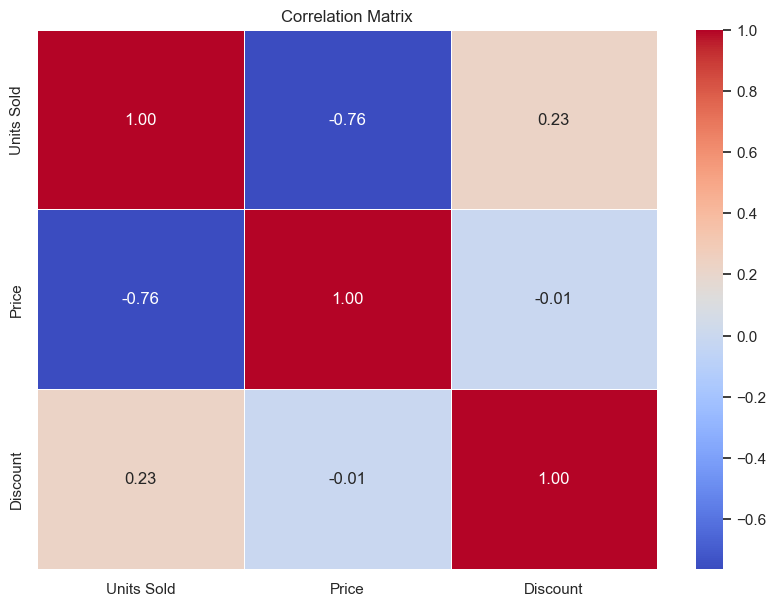

In [21]:
print("\nCorrelation Matrix Heatmap (Numerical Features including Revenue):")

numeric_df = df.select_dtypes(include = np.number)
plt.figure(figsize=(10,7))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot= True, cmap = "coolwarm", fmt =".2f", linewidths = 0.5)
plt.title("Correlation Matrix")

plt.show()


Analyzing relationships between categorical features and Revenue:


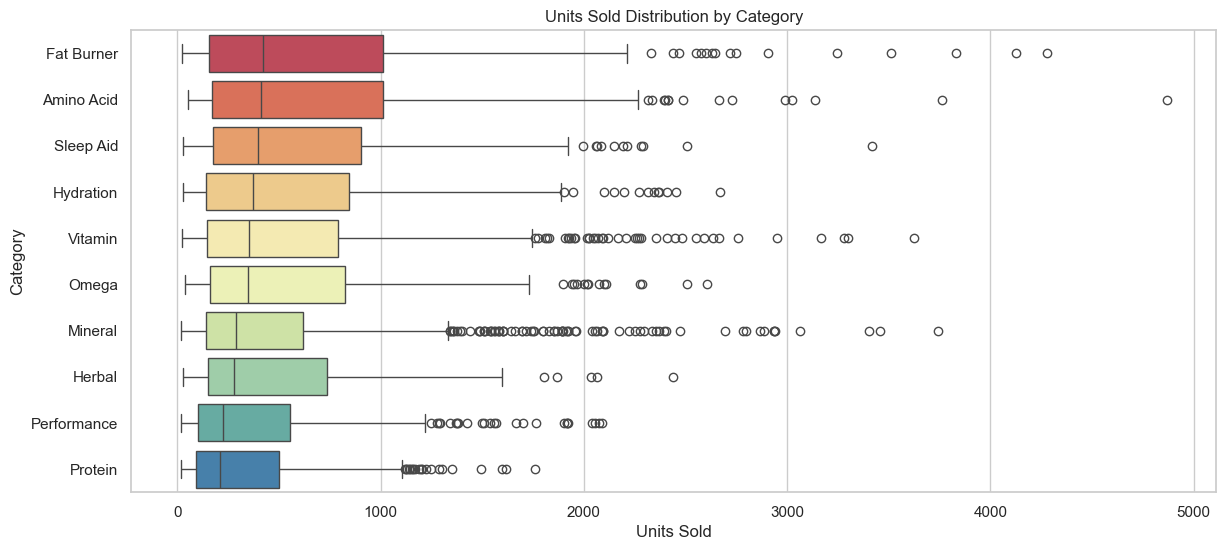

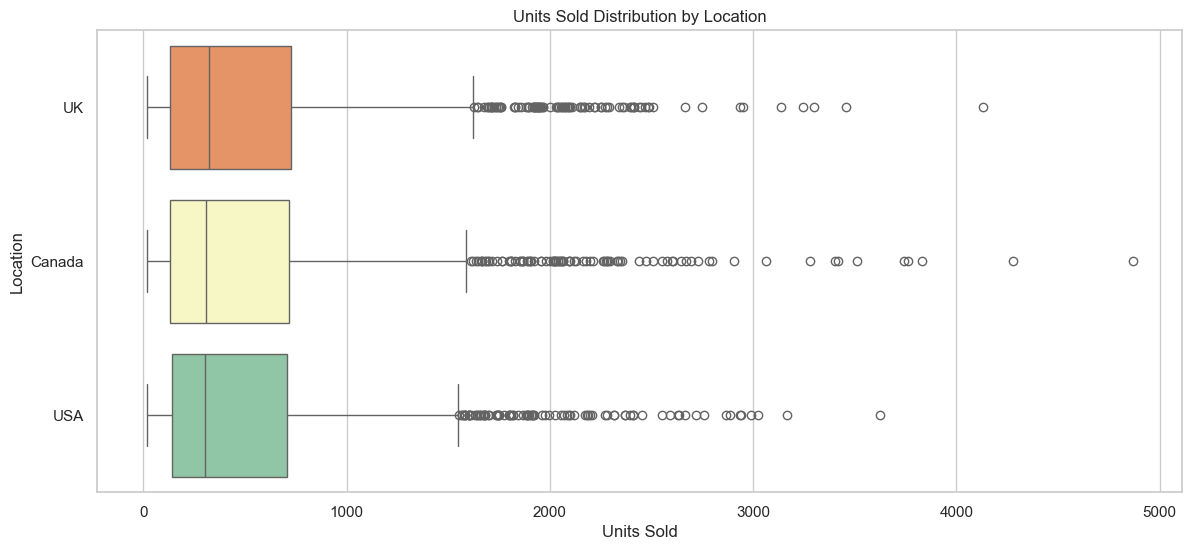

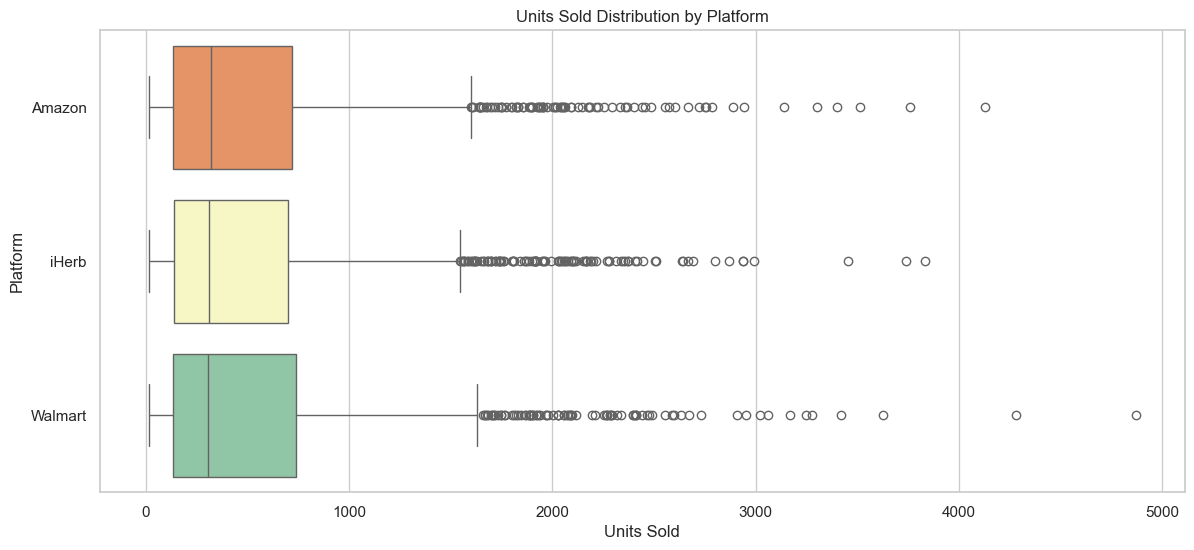

In [22]:
print("\nAnalyzing relationships between categorical features and Revenue:")
categorical_features = ["Category", "Location", "Platform"]

for col in categorical_features:
    plt.figure(figsize=(14, 6))
    order = df.groupby(col)["Units Sold"].median().sort_values(ascending=False).index
    sns.boxplot(y=col, x="Units Sold", data=df, order=order, palette="Spectral")
    plt.title(f"Units Sold Distribution by {col}")
    plt.xlabel("Units Sold")
    plt.ylabel(col)
    plt.show()
    print("=" * 130)

In [24]:
print("\nPerforming One-Hot Encoding on categorical features...")
categorical_cols = ["Category", "Location", "Platform"]

df_processed = df.copy()
df_processed = pd.get_dummies(df_processed, columns = categorical_cols, drop_first = True)

df_processed.head()


Performing One-Hot Encoding on categorical features...


,Date,Product Name,Units Sold,Price,Discount,Category_Fat Burner,Category_Herbal,Category_Hydration,Category_Mineral,Category_Omega,Category_Performance,Category_Protein,Category_Sleep Aid,Category_Vitamin,Location_UK,Location_USA,Platform_Walmart,Platform_iHerb
0,2020-01-06,Whey Protein,161,31.98,0.03,False,False,False,False,False,False,True,False,False,False,False,True,False
1,2020-01-06,Vitamin C,135,42.51,0.04,False,False,False,False,False,False,False,False,True,True,False,False,False
2,2020-01-06,Fish Oil,2604,12.91,0.25,False,False,False,False,True,False,False,False,False,False,False,False,False
3,2020-01-06,Multivitamin,949,16.07,0.08,False,False,False,False,False,False,False,False,True,False,False,True,False
4,2020-01-06,Pre-Workout,551,35.47,0.25,False,False,False,False,False,True,False,False,False,False,False,False,True


In [26]:
df_processed.shape

(4384, 18)

In [28]:
print("\nSelecting features (X) and target (y)...")

y = df_processed["Units Sold"]

columns_to_drop = [ "Product Name", "Date", "Units Sold"]

X = df_processed.drop(columns = columns_to_drop)

print("Target variable 'y' shape:", y.shape)
print("Features 'X' shape:", X.shape)


Selecting features (X) and target (y)...
Target variable 'y' shape: (4384,)
Features 'X' shape: (4384, 15)


In [30]:
print("\nSplitting data into training and testing sets...")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

print("Training set shape (X_train):", X_train.shape)
print("Testing set shape (X_test):", X_test.shape)
print("Training target shape (y_train):", y_train.shape)
print("Testing target shape (y_test):", y_test.shape)


Splitting data into training and testing sets...
Training set shape (X_train): (3507, 15)
Testing set shape (X_test): (877, 15)
Training target shape (y_train): (3507,)
Testing target shape (y_test): (877,)


In [32]:
print("Building and evaluating Linear Regression model...")

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"  Mean Absolute Error (MAE): {mae_linear:.2f}")
print(f"  Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_linear:.2f}")
print(f"  R-squared (R²): {r2_linear:.4f}")

Building and evaluating Linear Regression model...
  Mean Absolute Error (MAE): 236.19
  Mean Squared Error (MSE): 130374.56
  Root Mean Squared Error (RMSE): 361.07
  R-squared (R²): 0.6587


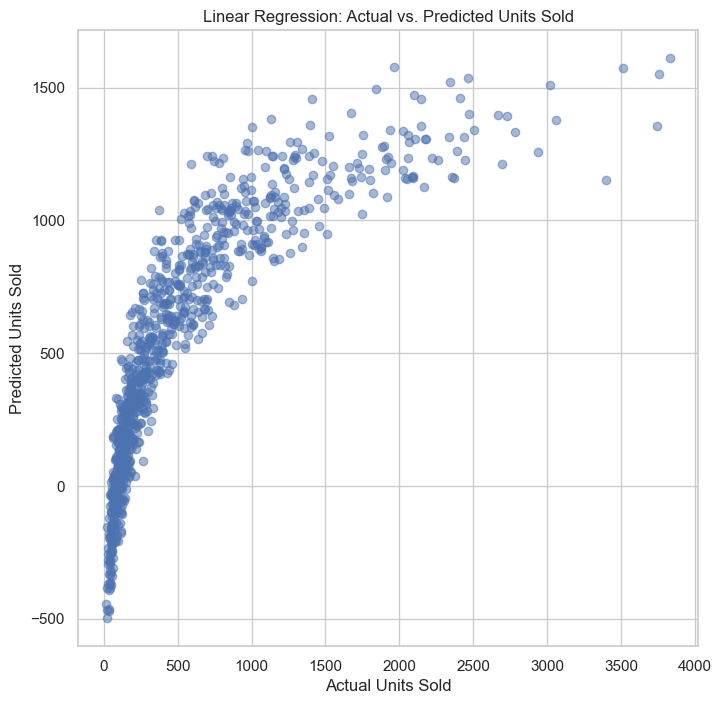

In [33]:
plt.figure(figsize = (8, 8))
plt.scatter(y_test, y_pred_linear, alpha=0.5)
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Linear Regression: Actual vs. Predicted Units Sold")

plt.grid(True)
plt.show()

In [35]:
print("Building and evaluating Random Forest Regression model...")

rf_model = RandomForestRegressor(random_state = 42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"  Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"  R-squared (R²): {r2_rf:.4f}")

Building and evaluating Random Forest Regression model...
  Mean Absolute Error (MAE): 163.42
  Mean Squared Error (MSE): 86417.66
  Root Mean Squared Error (RMSE): 293.97
  R-squared (R²): 0.7738


In [36]:
# 5. Compare with Linear Regression
print("\n--- Comparison ---")
print(f"Linear Regression R²: {r2_linear:.4f}")
print(f"Random Forest R²:     {r2_rf:.4f} (Test Set)")

print(f"\nLinear Regression RMSE: {rmse_linear:.2f}")
print(f"Random Forest RMSE:     {rmse_rf:.2f}")

if r2_rf > r2_linear:
    print("\nRandom Forest performed better on Test Set (higher R²).")
elif r2_rf < r2_linear:
    print("\nLinear Regression performed better on Test Set (higher R²).")
else:
    print("\nBoth models performed similarly on Test Set based on R².")



--- Comparison ---
Linear Regression R²: 0.6587
Random Forest R²:     0.7738 (Test Set)

Linear Regression RMSE: 361.07
Random Forest RMSE:     293.97

Random Forest performed better on Test Set (higher R²).


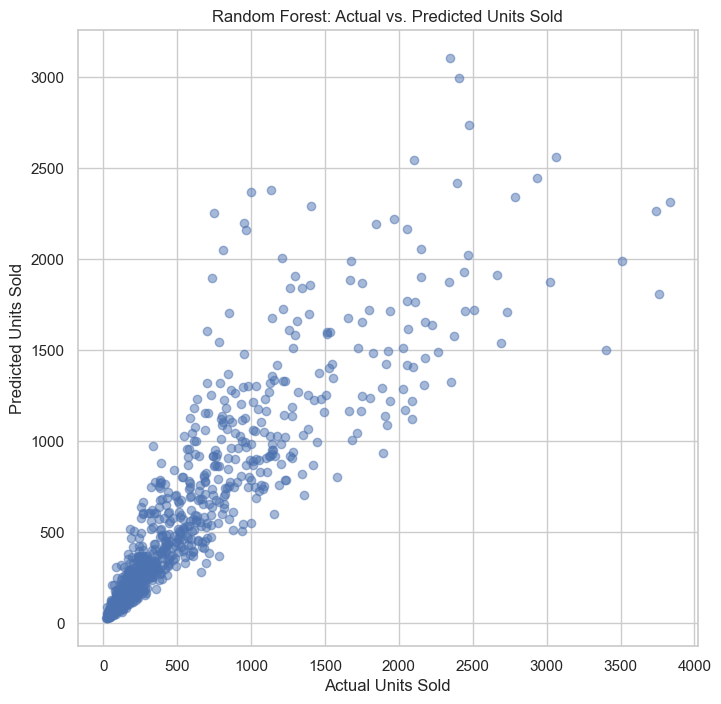

In [37]:
plt.figure(figsize = (8, 8))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Random Forest: Actual vs. Predicted Units Sold")
plt.grid(True)
plt.show()

Calculating and plotting feature importances from Random Forest...

Top 10 Most Important Features:


Price                   0.780940
Discount                0.112021
Category_Protein        0.026496
Category_Performance    0.014283
Category_Fat Burner     0.012178
Category_Mineral        0.008718
Platform_Walmart        0.008337
Location_UK             0.007617
Platform_iHerb          0.007525
Location_USA            0.006196
dtype: float64

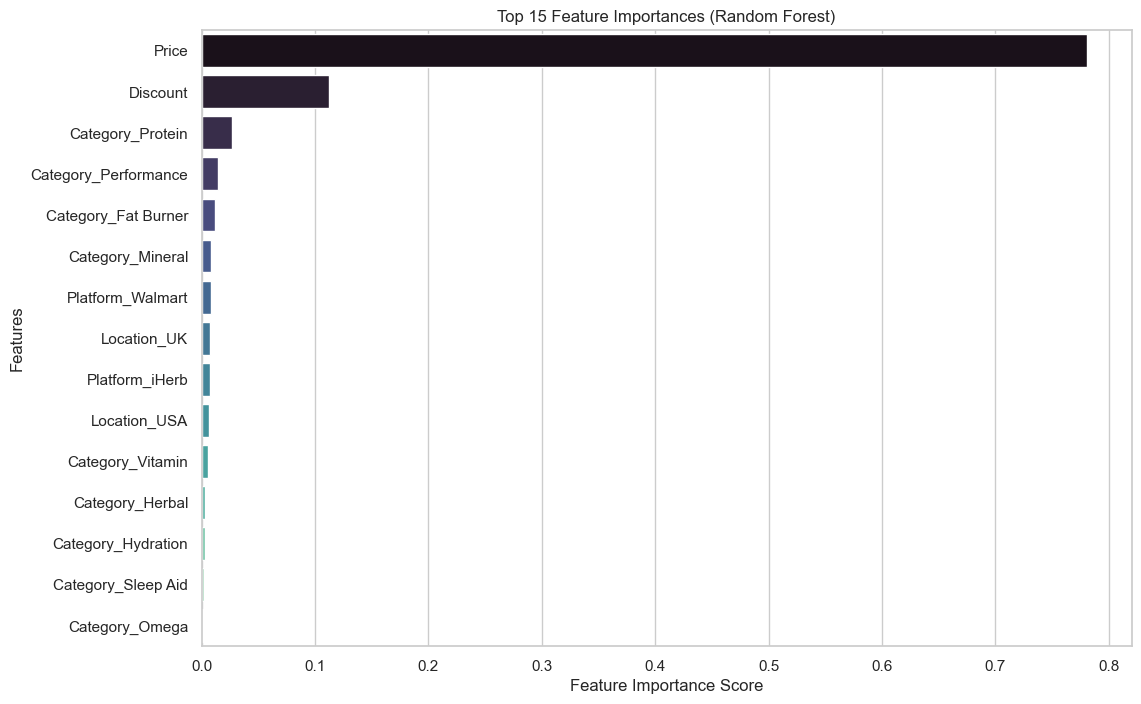

In [38]:
# Calculate and visualize feature importances from Random Forest

print("Calculating and plotting feature importances from Random Forest...")

# 1. Access feature importances
importances = rf_model.feature_importances_

# 2. Create a pandas Series with feature names
feature_names = X_train.columns
feature_importance_series = pd.Series(importances, index = feature_names)

# 3. Sort and plot
sorted_importances = feature_importance_series.sort_values(ascending = False)

print("\nTop 10 Most Important Features:")
display(sorted_importances.head(10))  # Use display for better formatting

plt.figure(figsize = (12, 8))
# Plotting only the top 20 for clarity if there are many features
num_features_to_plot = min(20, len(sorted_importances))
sns.barplot(
    x = sorted_importances.head(num_features_to_plot),
    y = sorted_importances.head(num_features_to_plot).index,
    palette = "mako",
)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title(f"Top {num_features_to_plot} Feature Importances (Random Forest)")
plt.show()
